In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.listdir("/content/drive/MyDrive")

['Untitled document (2).gdoc',
 'Untitled document (1).gdoc',
 'Resume.gdoc',
 'Untitled document.gdoc',
 'Copy of Practise 1 (2).xlsx',
 'Copy of Practise 1 (3).gsheet',
 'Copy of Practise 1 (2).gsheet',
 'Copy of MOCK_Updated.gsheet',
 'Copy of Practise 1 (1).xlsx',
 'Copy of Practise 1 (1).gsheet',
 'Copy of Practise 1.xlsx',
 'Copy of Practise 1.gsheet',
 'Iris.csv',
 'Colab Notebooks',
 'deep learning course',
 'diabetes_prediction_dataset.csv',
 'rnn project.ipynb',
 'qoute_dataset.csv',
 'lstm_model.h5',
 'Fake.csv',
 'True.csv',
 'TSLA.csv',
 'Untitled',
 'lstm_project.ipynb']

In [ ]:
import pandas as pd

data = pd.read_csv('/content/drive/MyDrive/TSLA.csv')

data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800,5.000,3.508,4.778,4.778,93831500
1,2010-06-30,5.158,6.084,4.660,4.766,4.766,85935500
2,2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000
3,2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000
4,2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [ ]:
data = data[['Close']]
data.head()

,Close
0,4.778
1,4.766
2,4.392
3,3.840
4,3.222


In [ ]:
scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(data)

In [ ]:
X = []
y = []

time_step = 10

for i in range(time_step, len(data_scaled)):
    X.append(data_scaled[i-time_step:i, 0])
    y.append(data_scaled[i, 0])

X = np.array(X)
y = np.array(y)

In [ ]:
X = X.reshape(X.shape[0], X.shape[1], 1)

In [ ]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
model = Sequential()

model.add(SimpleRNN(50, return_sequences=True, input_shape=(X.shape[1],1)))
model.add(SimpleRNN(50))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 10, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(X_train, y_train, epochs=100, batch_size=128)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.0000e+00 - loss: 1.2887e-06
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 1.0604e-06
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 1.0706e-06
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 1.0530e-06
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 1.0492e-06
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 1.0557e-06
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 1.0492e-06
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 1.1079e-06
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 1.1736e-06
Epoch 10/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 1.0626e-06
Epoch 11/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.00

In [ ]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test_actual, predictions)
mse = mean_squared_error(y_test_actual, predictions)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

MAE: 19.016055728124172
MSE: 862.1691092798169
RMSE: 29.36271631303577


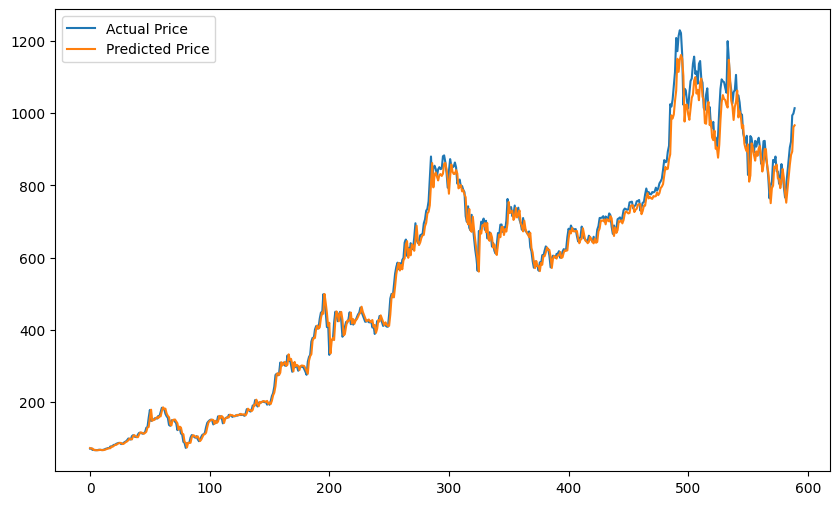

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(y_test_actual, label='Actual Price')
plt.plot(predictions, label='Predicted Price')

plt.legend()
plt.show()